In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from Cinc_ECG_loader import load_Cinc_ECG
from layers.Autoformer_EncDec import series_decomp_input
os.chdir('/media/lscsc/nas/xiangyu/Compare/autoformer_g_2b_SE/')

/media/lscsc/nas/xianping/Anaconda3/envs/transgan/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
gpu = "cuda:0"

# model
model = torch.load('models/checkpoint_800.pth')
gen_model = model['gen_model'].to(gpu)

# trend
train_set = load_Cinc_ECG(syn_len=900)
real_data = []
   
for i in range(len(train_set)):
    real_data_i = train_set[i][0].squeeze(1)
    real_data_i = np.swapaxes(real_data_i,0,1)
    real_data.append(real_data_i)
real_data = np.array(real_data, dtype=np.float32)

decomp = series_decomp_input([5, 25])
_, trend1, trend2 = decomp(torch.from_numpy(real_data))
trend1 = trend1.to(gpu)
trend1 = torch.mean(trend1, axis=0)
trend2 = trend2.to(gpu)
trend2 = torch.mean(trend2, axis=0)

# gen
z = torch.cuda.FloatTensor(np.random.normal(0, 1, (32, 300))).cuda(gpu)
fake_imgs = gen_model(z, trend1, trend2)

fake_imgs = fake_imgs.cpu().detach()
fake_imgs = fake_imgs.numpy()

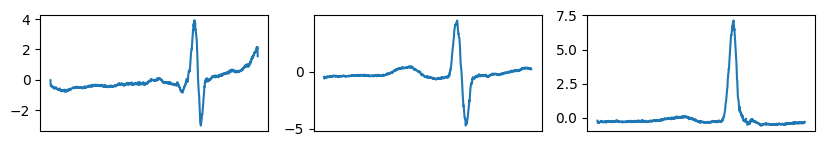

In [11]:
plt.figure(figsize=(10, 1.5))
plt.subplot(1, 3, 1)
plt.xticks([])
plt.plot(fake_imgs[0,0,0,:])

plt.subplot(1, 3, 2)
plt.xticks([])
plt.plot(fake_imgs[1,0,0,:])

plt.subplot(1, 3, 3)
plt.xticks([])
plt.plot(fake_imgs[2,0,0,:])

plt.savefig('real_data3.png')
plt.show()
plt.close()